# Creating a TPF and LCF with multiple apertures

We might want to create lightcurves from different apertures and compare the results. This tutorial will demonstrate how to do this.

In [1]:
from tess_asteroids import MovingTPF
import matplotlib.pyplot as plt

## Create the TPC and LCF

In [2]:
# Initialise MovingTPF for asteroid 1980 VR1 in TESS sector 1, camera 1, CCD 1
target = MovingTPF.from_name("1980 VR1", sector=1, camera=1, ccd=1)

# Retrieve the data, perform a background correction and create the pixel quality mask.
# Note: these steps are normally run as part of `make_tpf()`. To create multiple apertures, we must run them ourselves.
target.get_data()
target.reshape_data()
target.background_correction()
target.create_pixel_quality()

Warning from TESSSpacecraft(): {message : ErfaWarning('ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"'), category : 'ErfaWarning', filename : '/Users/atuson/miniforge3/envs/tess-asteroids/lib/python3.10/site-packages/erfa/core.py', lineno : 133, line : None}
Warning from `prf.evaluate()`: {message : LKPRFWarning('`targets` contains collateral pixels: Column(s) >= 2093 '), category : 'LKPRFWarning', filename : '/Users/atuson/miniforge3/envs/tess-asteroids/lib/python3.10/site-packages/lkprf/tessprf.py', lineno : 56, line : None}
The PRF model contained nans in the first frame (cadence number 273). The model was replaced with that from the following frame (cadence number 274).
Warning from `prf.evaluate()`: {message : LKPRFWarning('`targets` contains collateral pixels: Column(s) >= 2093 '), category : 'LKPRFWarning', filename : '/Users/atuson/miniforge3/envs/tess-asteroids/lib/python3.10/site-packages/lkprf/tessprf.py', lineno : 56, line : None}
The PRF model contained nans in

In [3]:
# Initialise a lightcurve dictionary
lc = {
	"aperture": [],
}

# Create three PRF apertures using different thresholds and extract a lightcurve for each.
for thresh in [0.01,0.05,0.1]:
    
    target.create_aperture(method="prf", threshold=thresh)
    lc["aperture"].append(target._aperture_photometry())

# Add PSF photometry
lc["psf"] = target._psf_photometry()

# Create HDUList for TPF and LCF
target.tpf_hdulist = target._make_tpf_hdulist(ap_masks=[lc["aperture"][i]["ap_mask"] for i in range(len(lc["aperture"]))], 
                                              ap_methods=[lc["aperture"][i]["ap_method"] for i in range(len(lc["aperture"]))], 
                                              ap_params=[lc["aperture"][i]["ap_param"] for i in range(len(lc["aperture"]))])
target.lc_hdulist = target._make_lc_hdulist(lc=lc)

"""
# If we wanted to save these to files, we would run:
target._save_hdulist(file_type="tpf")
target._save_hdulist(file_type="lc")
""";

The PRF model contained nans in the first frame (cadence number 273). The model was replaced with that from the following frame (cadence number 274).
The PRF model contained nans in the first frame (cadence number 273). The model was replaced with that from the following frame (cadence number 274).
The PRF model contained nans in the first frame (cadence number 273). The model was replaced with that from the following frame (cadence number 274).
The PRF model contained nans in the first frame (cadence number 273). The model was replaced with that from the following frame (cadence number 274).
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 959/959 [00:00<00:00, 5788.19it/s]


## Understanding the contents of the TPF and LCF

The TPF HDUList has a similar structure as the TPF we created in Tutorial 1. Important differences:
- There is now an HDU per aperture (APERTURE0, APERTURE1 and APERTURE2). These contain the flattened apertures.
- In the EXTRAS HDU, there is now a column containing each aperture as a function of time (APERTURE0, APERTURE1 and APERTURE2).

In [4]:
target.tpf_hdulist.info()

Filename: (No file associated with this HDUList)
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      55   ()      
  1  PIXELS        1 BinTableHDU    202   972R x 10C   ['D', 'E', 'I', '121E', '121E', '121E', '121E', 'J', 'E', 'E']   
  2  APERTURE0     1 ImageHDU        41   (11, 11)   int32   
  3  APERTURE1     1 ImageHDU        41   (11, 11)   int32   
  4  APERTURE2     1 ImageHDU        41   (11, 11)   int32   
  5  EXTRAS        1 BinTableHDU     50   972R x 12C   ['D', 'I', 'D', 'E', 'E', 'E', 'I', 'I', '121I', '121J', '121J', '121J']   


In [5]:
target.tpf_hdulist[5].columns

ColDefs(
    name = 'TIME'; format = 'D'; unit = 'BJD - 2457000, days'; disp = 'D14.7'
    name = 'CADENCENO'; format = 'I'
    name = 'ORIGINAL_TIME'; format = 'D'; unit = 'BJD - 2457000, days'; disp = 'D14.7'
    name = 'ORIGINAL_TIMECORR'; format = 'E'; unit = 'd'; disp = 'E14.7'
    name = 'RA_PRED'; format = 'E'; unit = 'deg'; disp = 'E14.7'
    name = 'DEC_PRED'; format = 'E'; unit = 'deg'; disp = 'E14.7'
    name = 'CORNER1'; format = 'I'; unit = 'pixel'
    name = 'CORNER2'; format = 'I'; unit = 'pixel'
    name = 'PIXEL_QUALITY'; format = '121I'; disp = 'B16.16'; dim = '(11, 11)'
    name = 'APERTURE0'; format = '121J'; dim = '(11, 11)'
    name = 'APERTURE1'; format = '121J'; dim = '(11, 11)'
    name = 'APERTURE2'; format = '121J'; dim = '(11, 11)'
)

We can plot the flattened apertures. Notice that, as expected, the number of pixels in the aperture decreases as the threshold increases.

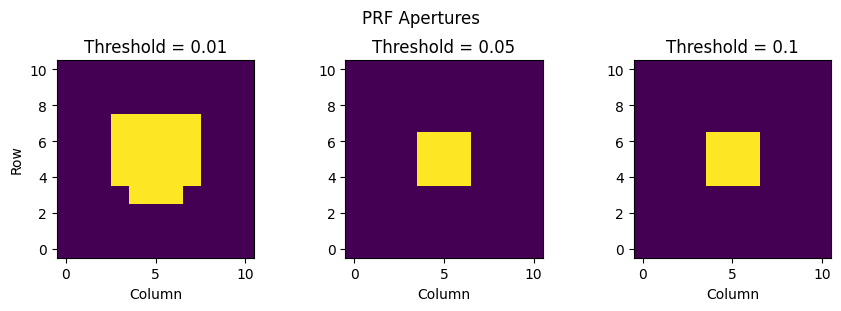

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(9,3))

ax1.imshow(target.tpf_hdulist["APERTURE0"].data, origin="lower")
ax1.set_xlabel("Column")
ax1.set_ylabel("Row")
ax1.set_title("Threshold = {}".format(target.tpf_hdulist["PRIMARY"].header["AP0_PAR"]))

ax2.imshow(target.tpf_hdulist["APERTURE1"].data, origin="lower")
ax2.set_xlabel("Column")
ax2.set_title("Threshold = {}".format(target.tpf_hdulist["PRIMARY"].header["AP1_PAR"]))

ax3.imshow(target.tpf_hdulist["APERTURE2"].data, origin="lower")
ax3.set_xlabel("Column")
ax3.set_title("Threshold = {}".format(target.tpf_hdulist["PRIMARY"].header["AP2_PAR"]))

fig.suptitle("PRF Apertures")
fig.tight_layout();

The LCF HDUList has a similar structure as the LCF we created in Tutorial 1. Important differences:
- There is now an HDU per aperture (LIGHTCURVE_AP0, LIGHTCURVE_AP1 and LIGHTCURVE_AP2). These contain the photometry extracted from each aperture.

In [7]:
target.lc_hdulist.info()

Filename: (No file associated with this HDUList)
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      55   ()      
  1  LIGHTCURVE_AP0    1 BinTableHDU     97   972R x 23C   ['D', 'I', 'J', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'I', 'E', 'I', 'I', 'E', 'E']   
  2  LIGHTCURVE_AP1    1 BinTableHDU     97   972R x 23C   ['D', 'I', 'J', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'I', 'E', 'I', 'I', 'E', 'E']   
  3  LIGHTCURVE_AP2    1 BinTableHDU     97   972R x 23C   ['D', 'I', 'J', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'I', 'E', 'I', 'I', 'E', 'E']   
  4  LIGHTCURVE_PSF    1 BinTableHDU     88   959R x 21C   ['D', 'E', 'E', 'E', 'I', 'J', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'I', 'E', 'I', 'E', 'E', 'E', 'E', 'E']   
  5  EXTRAS        1 BinTableHDU     61   972R x 14C   ['D', 'E', 'D', 'E', 'I', 'I', 'I', 'E', 'E', 'E', 'E', 'E', 'E', 'E']   


## Plot the results

Let's plot the three aperture lightcurves and the PSF lightcurve.

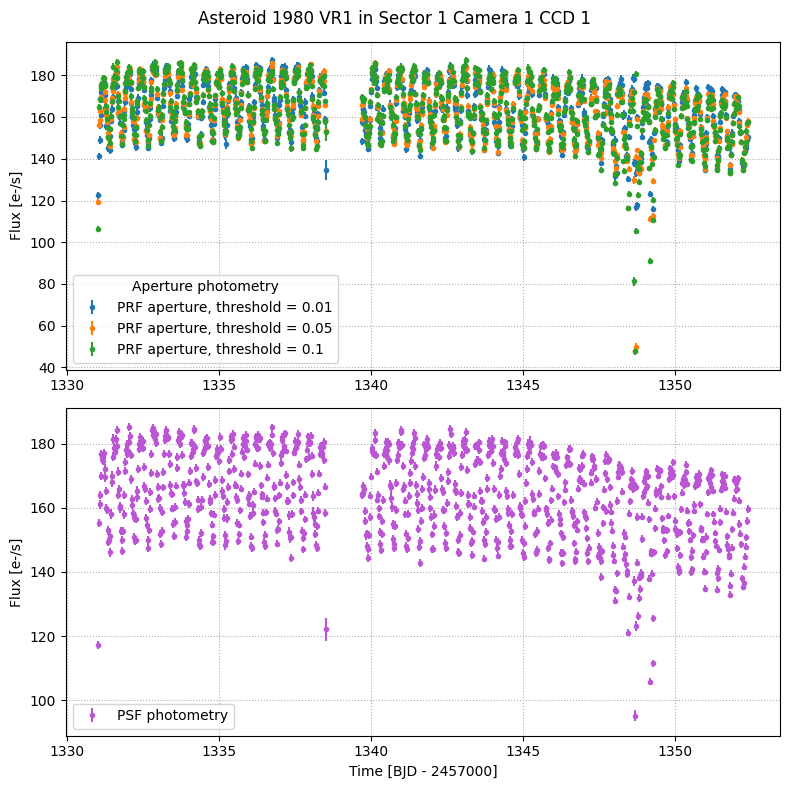

In [8]:
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(8,8))

for i, ap in enumerate(lc["aperture"]):
    ax1.errorbar(ap["time"], ap["flux"], yerr=ap["flux_err"], marker=".", ls="", label="PRF aperture, threshold = {}".format(lc["aperture"][i]["ap_param"]))
ax1.set_ylabel("Flux [e-/s]")
ax1.grid(ls=":")
ax1.legend(title="Aperture photometry", loc="lower left")

ax2.errorbar(lc["psf"]["time"], lc["psf"]["flux"], yerr=lc["psf"]["flux_err"], color="mediumorchid", marker=".", ls="", label="PSF photometry")
ax2.set_ylabel("Flux [e-/s]")
ax2.grid(ls=":")
ax2.set_xlabel("Time [BJD - 2457000]")
ax2.legend(loc="lower left")

fig.suptitle(f"Asteroid {target.target} in Sector {target.sector} Camera {target.camera} CCD {target.ccd}")
fig.tight_layout();

We can see that in this case, all three aperture lightcurves are very consistent!